In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches


#provided MHW value for your site in [m NAVD88]
MHW_ELEVATION_NAVD88 = 0.26 
#load the water level csv file for year 2024 [m NAVD88]
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv'

#load water level
water_NAVD_df = pd.read_csv(water_level_NAVD) # (m NAVD88)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values # (m NAVD88)
#converting daily water level (m NAVD88) to (m MHW)
daily_tidal_MHW = daily_tidal_levels_NAVD - MHW_ELEVATION_NAVD88 # (m MHW)

#loading CASCADE simulations
data = np.load (
    '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz' with keys: cascade

In [111]:
cascade_object = data['cascade'][0]

In [119]:
#exporting road elevations (m MHW)  for each domain for all years
results_list = []
target_years = range(0,100,1)
 
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            
            # only DOMAINS 14 to 54
            if 15 <= i <= 55:
                elevation_time_series = road_segment._road_ele_TS
                elevation = elevation_time_series[year]
                elev_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation (m MHW)': elevation,
                }
                results_list.append(elev_row)

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    road_df = pd.DataFrame(results_list)
    output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_Road_all.csv'

    road_df.to_csv(output_filename, index=False)
    print("Data for domains 14-54 successfully exported. First 5 rows:")
    print(road_df.head())

Data for domains 14-54 successfully exported. First 5 rows:
   Year  Domain  Road_Elevation (m MHW)
0     0      15                    1.45
1     0      16                    1.45
2     0      17                    1.45
3     0      18                    1.45
4     0      19                    1.45


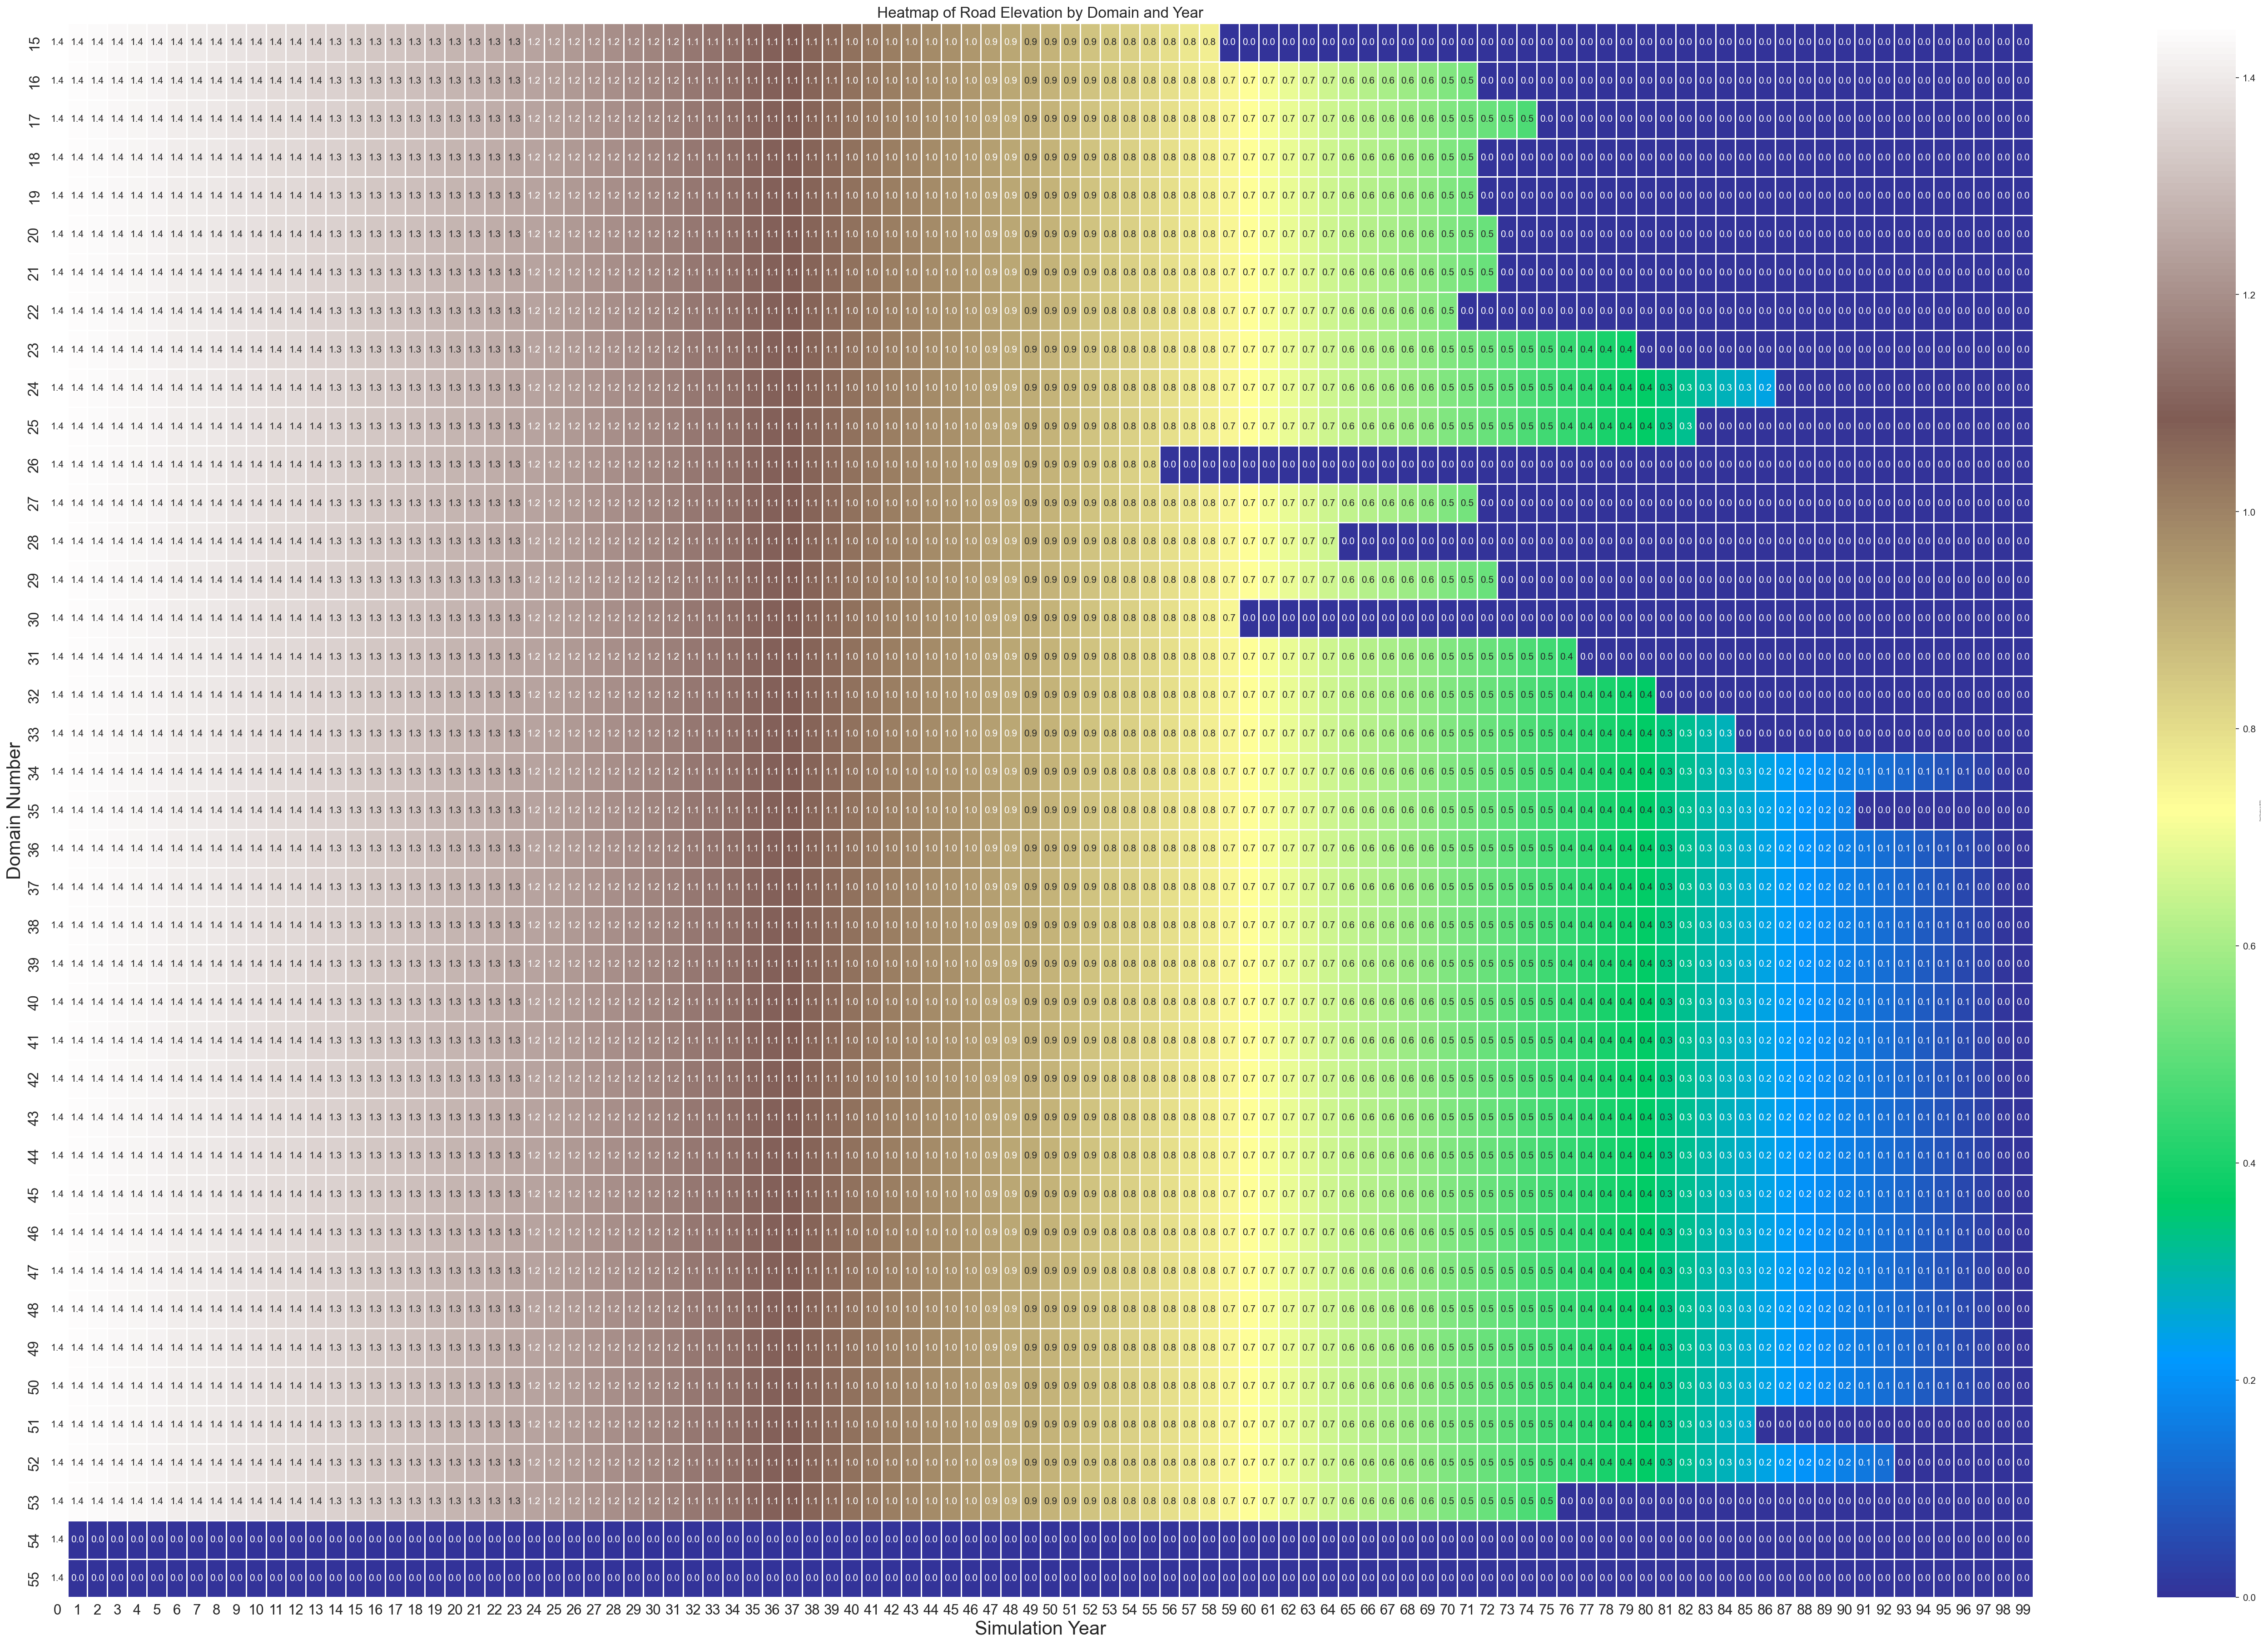

In [137]:
#plotting road elevation
# Load the CSV file into a DataFrame
file_path = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_Road_all.csv'
df = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df.pivot_table(index='Domain', columns='Year', values='Road_Elevation (m MHW)')

# Create the heatmap plot
plt.figure(figsize=(47, 30), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot= True, 
                 fmt=".1f", 
                 cmap='terrain', 
                 linewidths=.5,
                 cbar_kws={'label': 'Road Elevation (m MHW)'})
ax.collections[0].colorbar.set_label('Road Elevation (m MHW)', fontsize=2) 


ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)

plt.title('Heatmap of Road Elevation by Domain and Year', fontsize=16)
plt.ylabel('Domain Number', fontsize=20)
plt.xlabel('Simulation Year', fontsize=20)

# Show the plot
plt.show()

In [120]:
#export flood days and depth to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_flood_analysis_all.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    
    # flood days and depth analysis
    # Identify which days are flooded
    is_flooded = road_elevation < daily_tidal_MHW
    flooded_days = np.sum(is_flooded)
    
    # Calculate flood depth only on the days it flooded
    max_flood_depth = 0
    avg_flood_depth = 0
    
    if flooded_days > 0:
        # Calculate the depth for all flooded days
        flood_depths = daily_tidal_MHW[is_flooded] - road_elevation # (m MHW)
        
        # Find the maximum and average flood depth for the year
        max_flood_depth = np.max(flood_depths)
        avg_flood_depth = np.mean(flood_depths)

    # export the results
        
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation, # (m MHW)
        'Flooded_Days': flooded_days,
        'Max_Flood_Depth_m_MHW': max_flood_depth,   # (m MHW)
        'Avg_Flood_Depth_m_MHW': avg_flood_depth,   # (m MHW)
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_flood_analysis_all.csv'


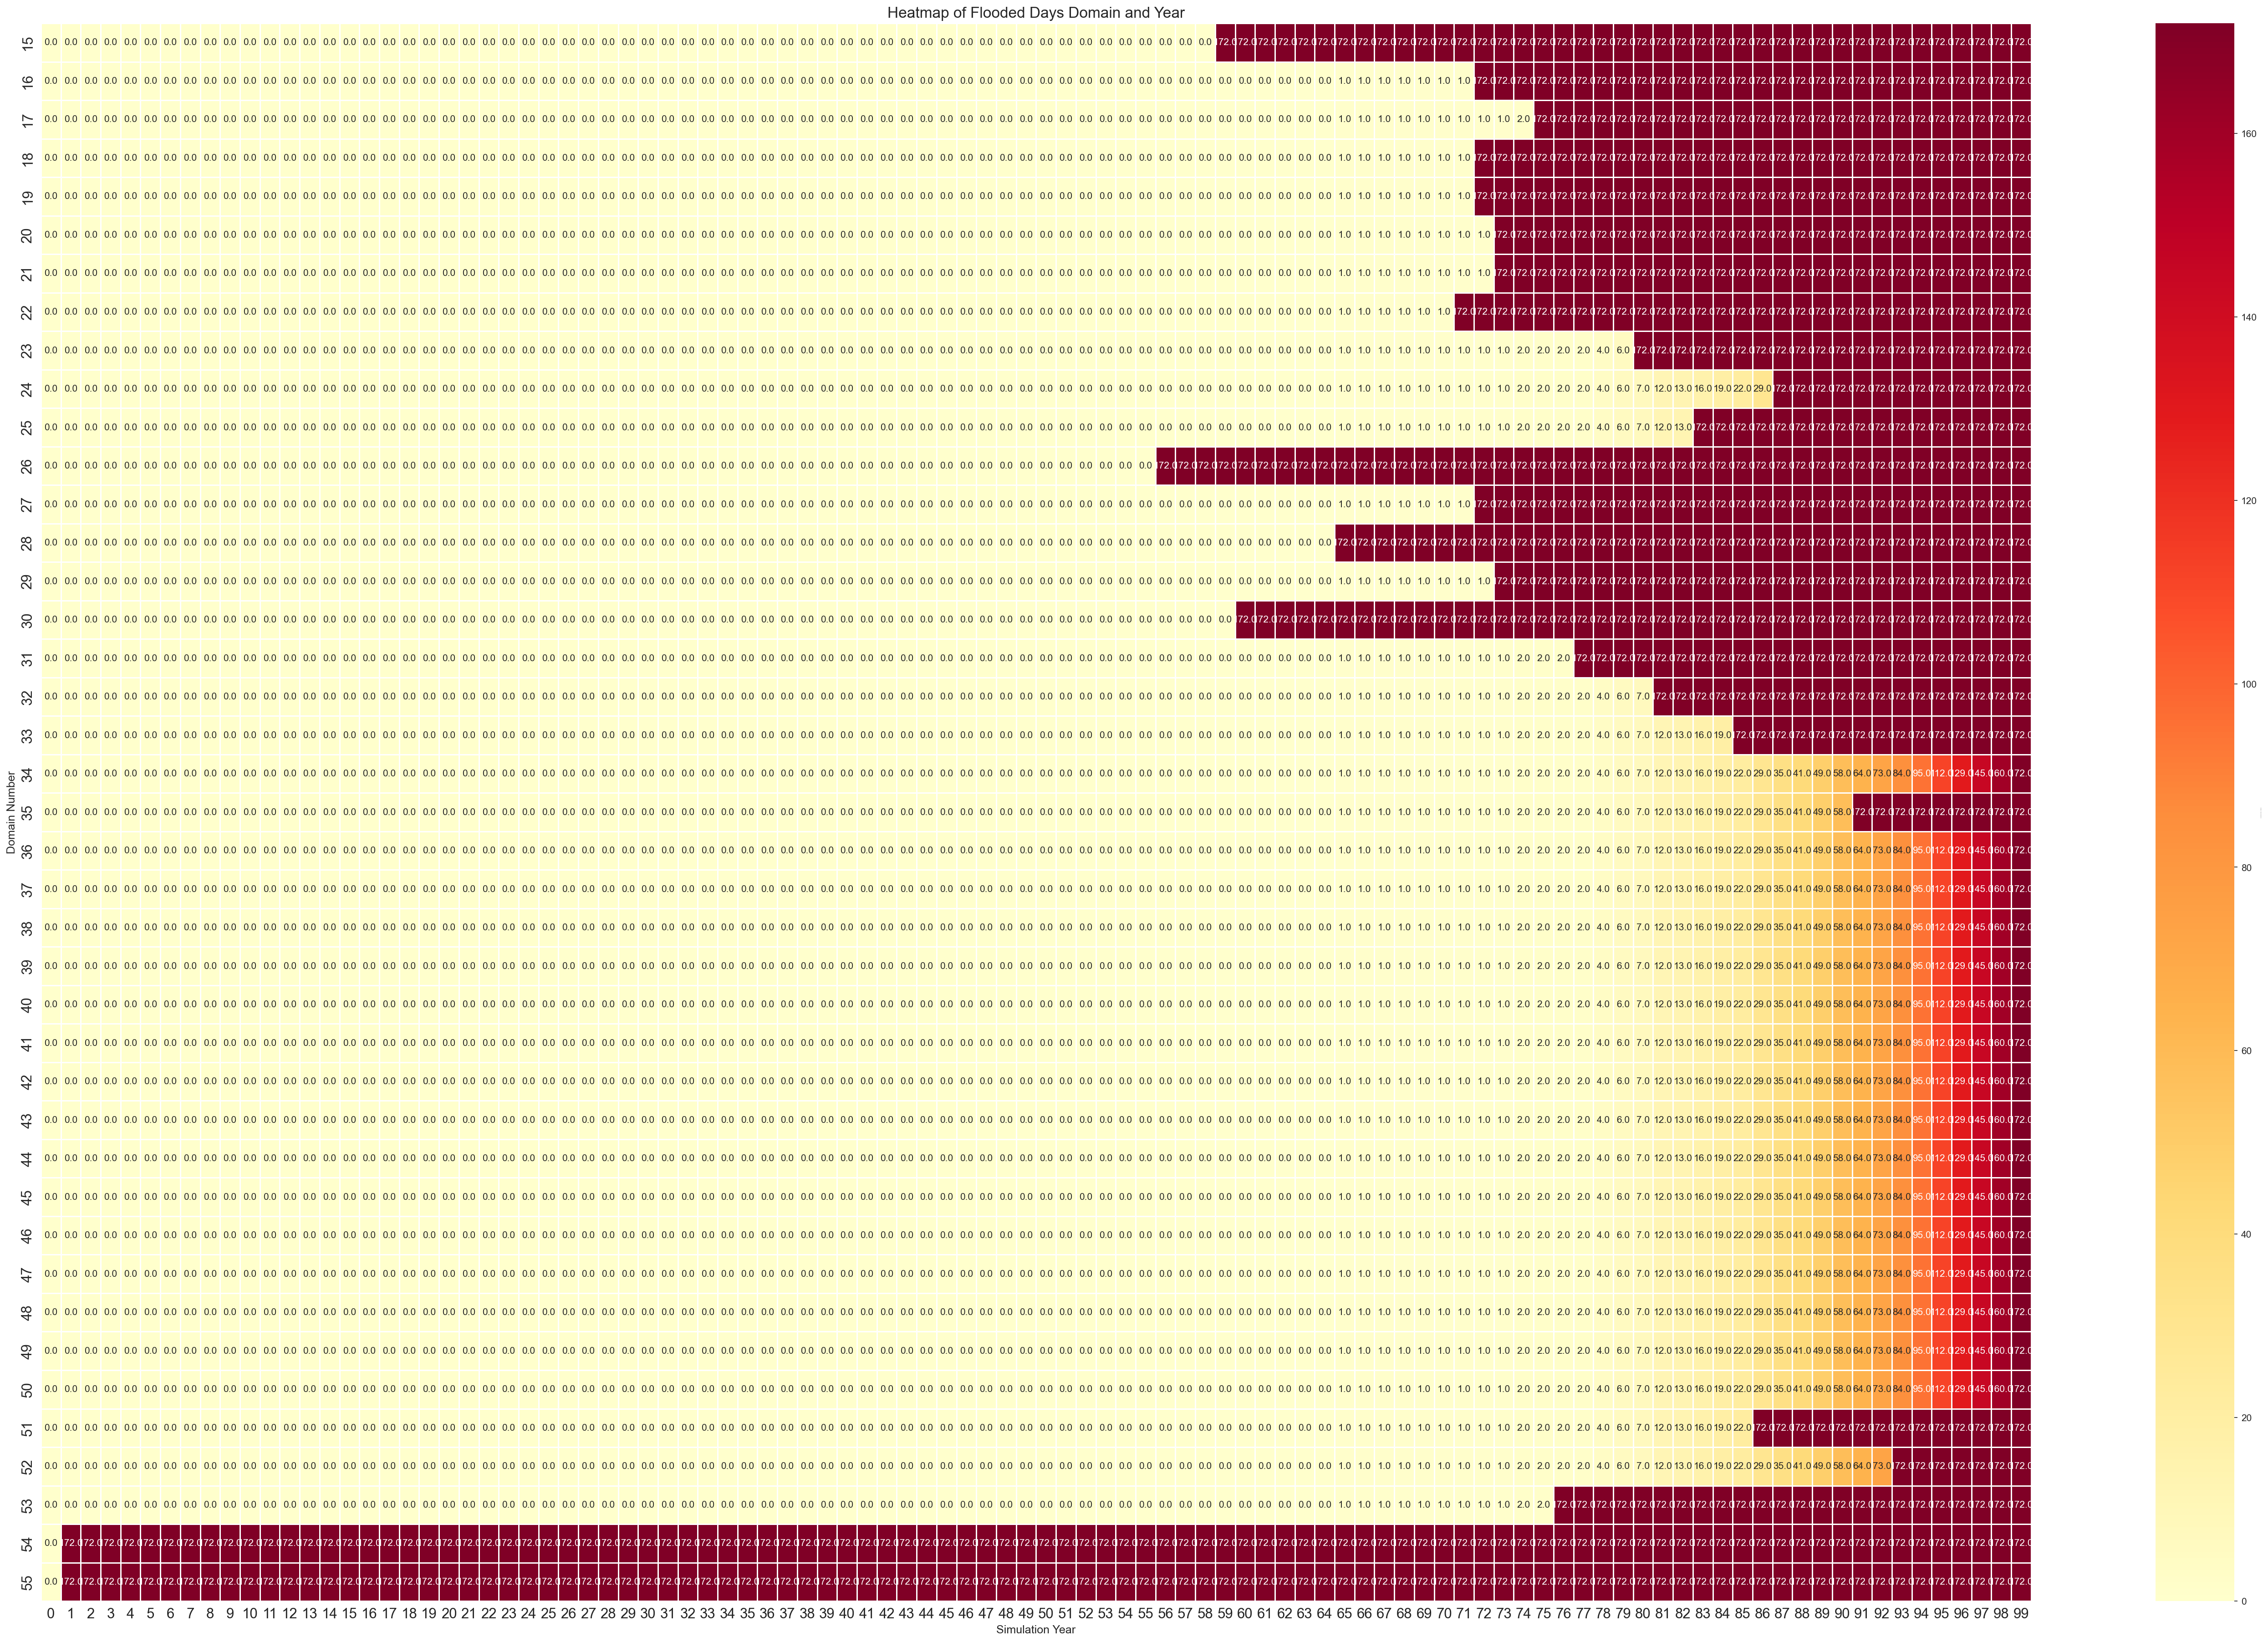

In [139]:
#plotting road elevation
# Load the CSV file into a DataFrame
file_path = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_flood_analysis_all.csv'
df_flood = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df_flood.pivot_table(index='Domain', columns='Year', values='Flooded_Days')

# Create the heatmap plot
plt.figure(figsize=(47, 30), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap='YlOrRd', 
                 linewidths=.5,
                 cbar_kws={'label': 'Flooded Days'})
ax.collections[0].colorbar.set_label('Road Elevation (m MHW)', fontsize=1) 


ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)

plt.title('Heatmap of Flooded Days Domain and Year', fontsize=16)
plt.ylabel('Domain Number', fontsize=12)
plt.xlabel('Simulation Year', fontsize=12)

# Show the plot
plt.show()

In [123]:
# identify the abondanded roads
abandonment_status = cascade_object.road_break

# Create a list of the numbers of the abandoned domains
abandoned_domains = [i for i, status in enumerate(abandonment_status) if status == 1]

if abandoned_domains:
    print(f"Roads in the following domains have been abandoned: {abandoned_domains}")
else:
    print("No domains were abandoned during the simulation.")

Roads in the following domains have been abandoned: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 51, 52, 53]


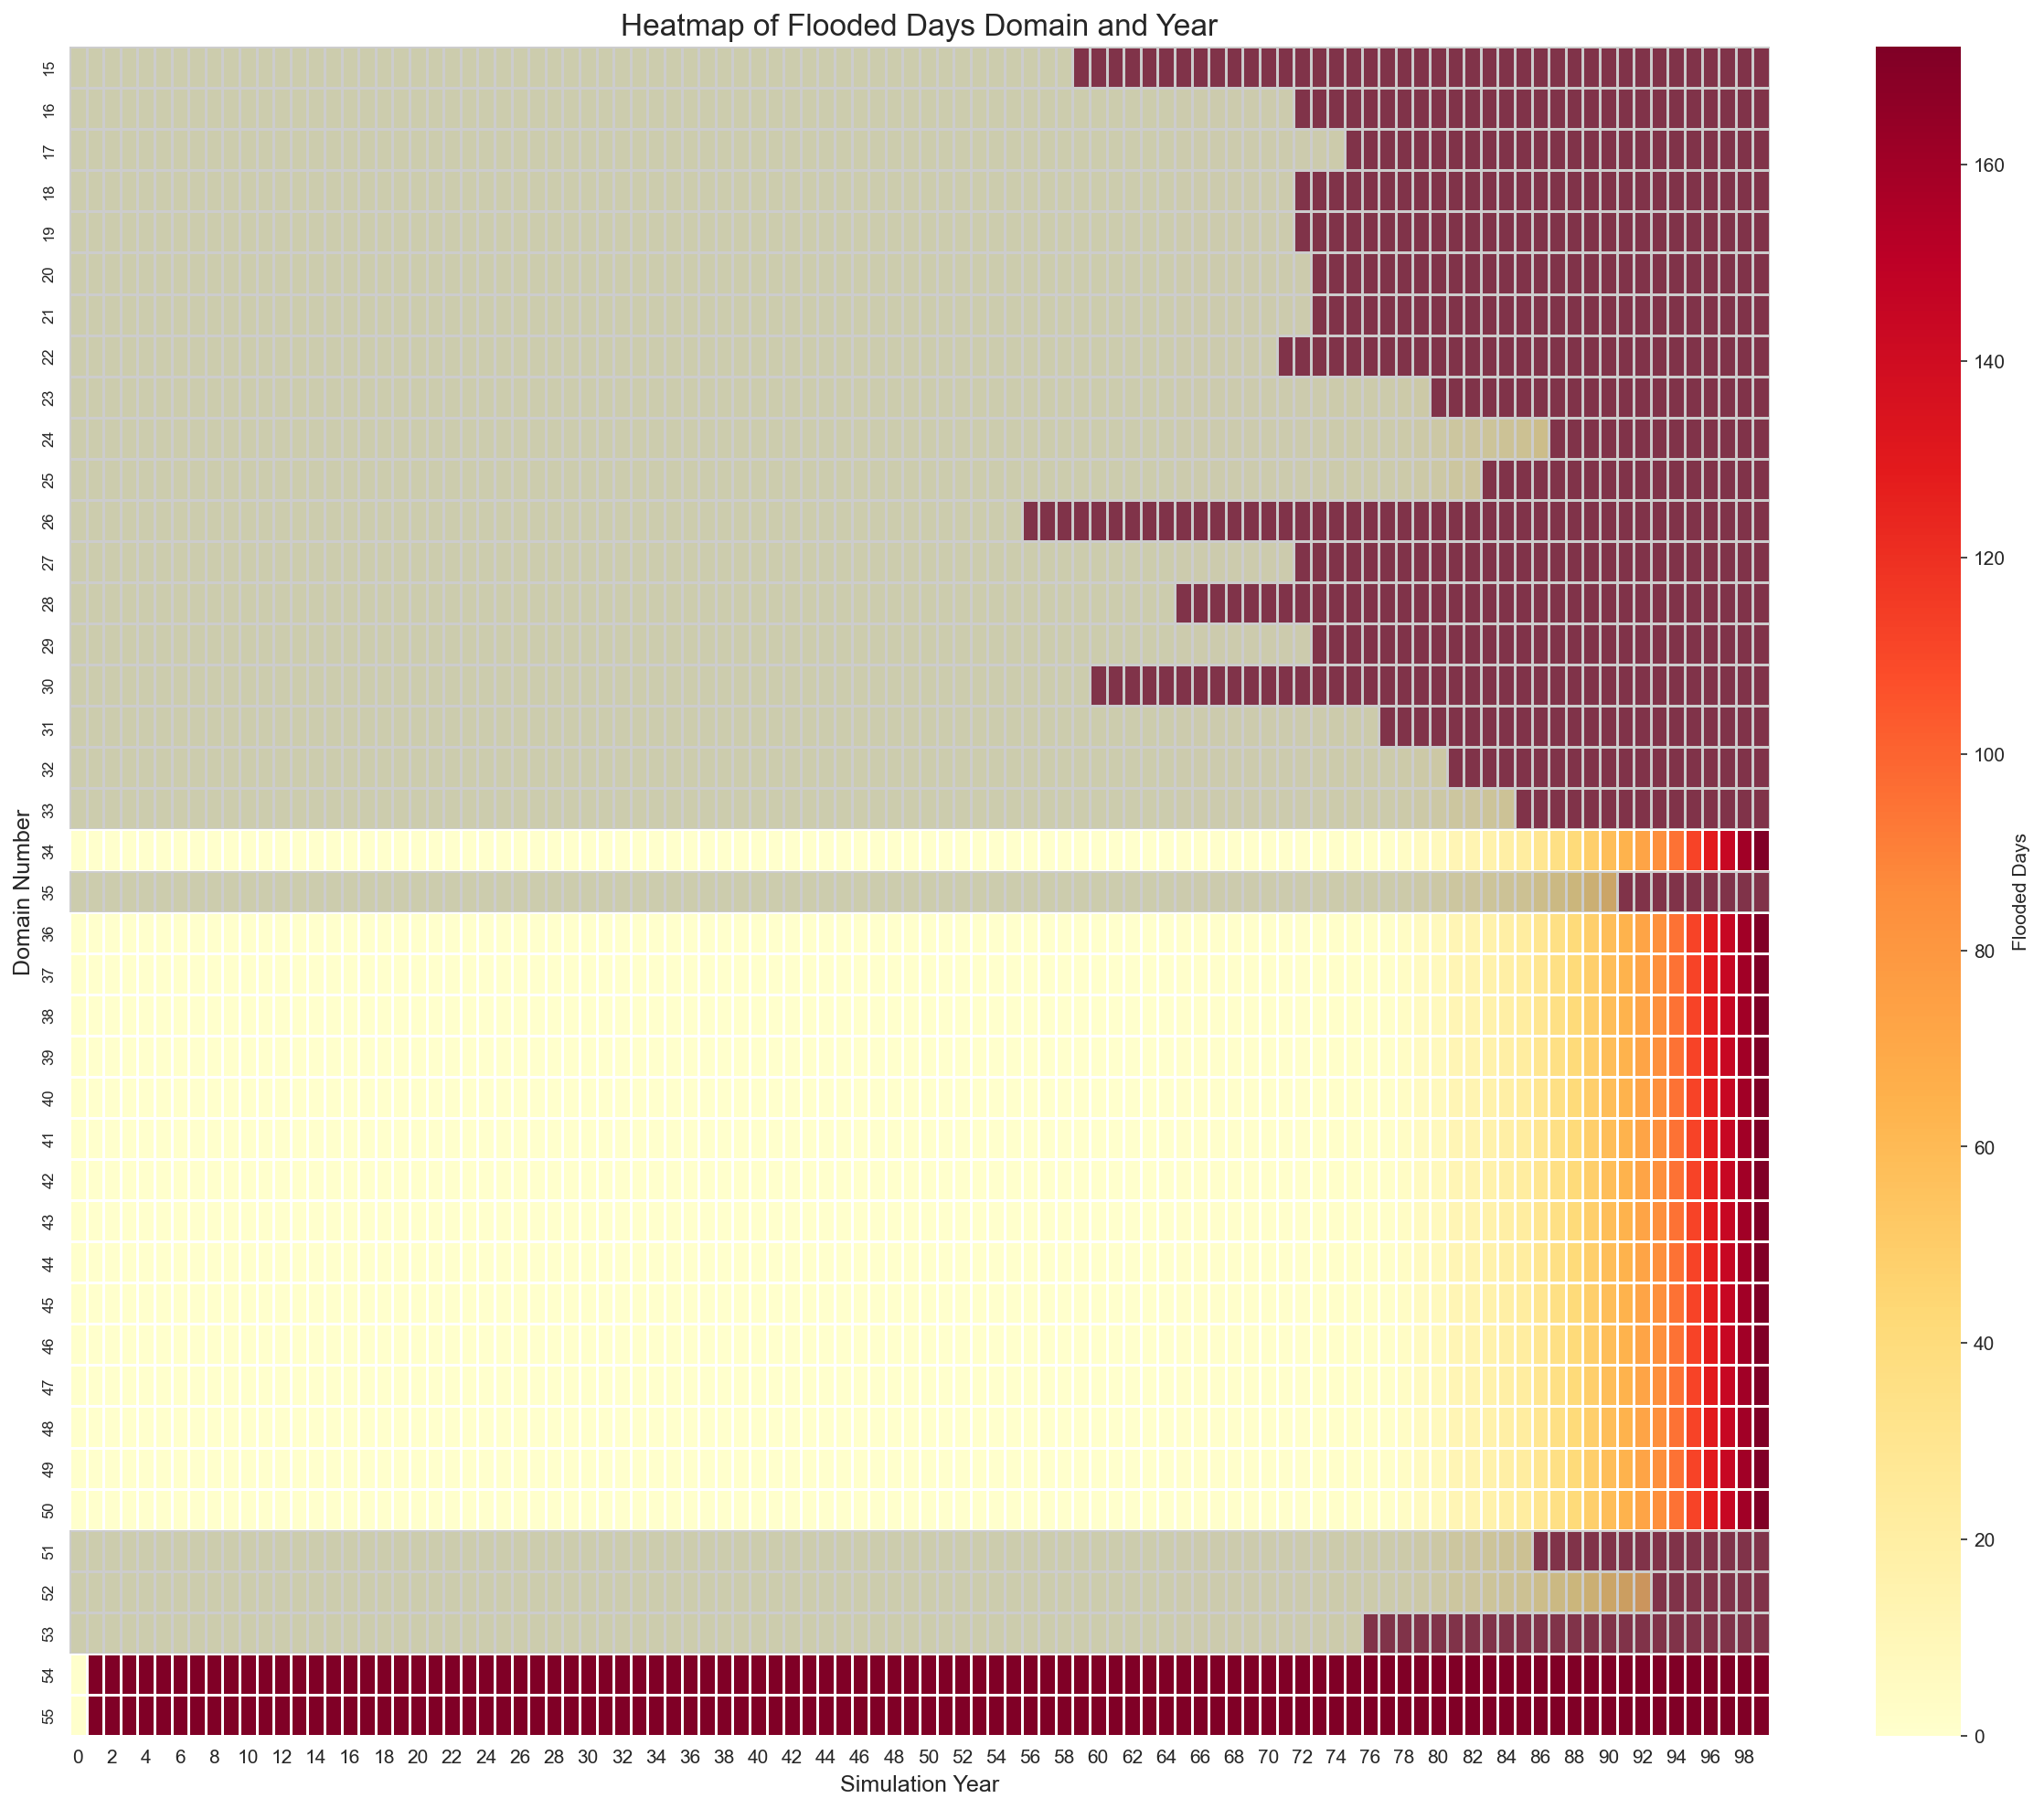

In [126]:
#highlight abandoned road on the flood plot
file_path = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/All_Years/OCR_I_Nourishment_S0_Accretional_Sink_flood_analysis_all.csv'
df_flood_days = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df_flood_days.pivot_table(index='Domain', columns='Year', values='Flooded_Days')

# Create the heatmap plot
plt.figure(figsize=(20, 16), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot=False, 
                 fmt=".2f", 
                 cmap='YlOrRd', 
                 linewidths=.5,
                 cbar_kws={'label': 'Flooded Days'})

# Define the list of domains you want to shade.
domains_to_highlight = abandoned_domains

y_labels = list(heatmap_data.index)

# Loop through the domains to highlight
for domain in domains_to_highlight:
    # Check if the domain exists in the plot
    if domain in y_labels:
        # Get the integer index (the row position) of the domain
        idx = y_labels.index(domain)
        
        # Add a transparent gray rectangle across the full width of the plot for that row
        # The y-coordinates correspond to the row indices (0 at the top).
        ax.add_patch(patches.Rectangle((0, idx), 
                                       len(heatmap_data.columns), 
                                       1, 
                                       facecolor='gray', 
                                       alpha=0.4, 
                                       lw=0)) # lw=0 to remove the border


ax.tick_params(axis='y', labelsize=8)

plt.title('Heatmap of Flooded Days Domain and Year', fontsize=16)
plt.ylabel('Domain Number', fontsize=12)
plt.xlabel('Simulation Year', fontsize=12)

# Show the plot
plt.show()


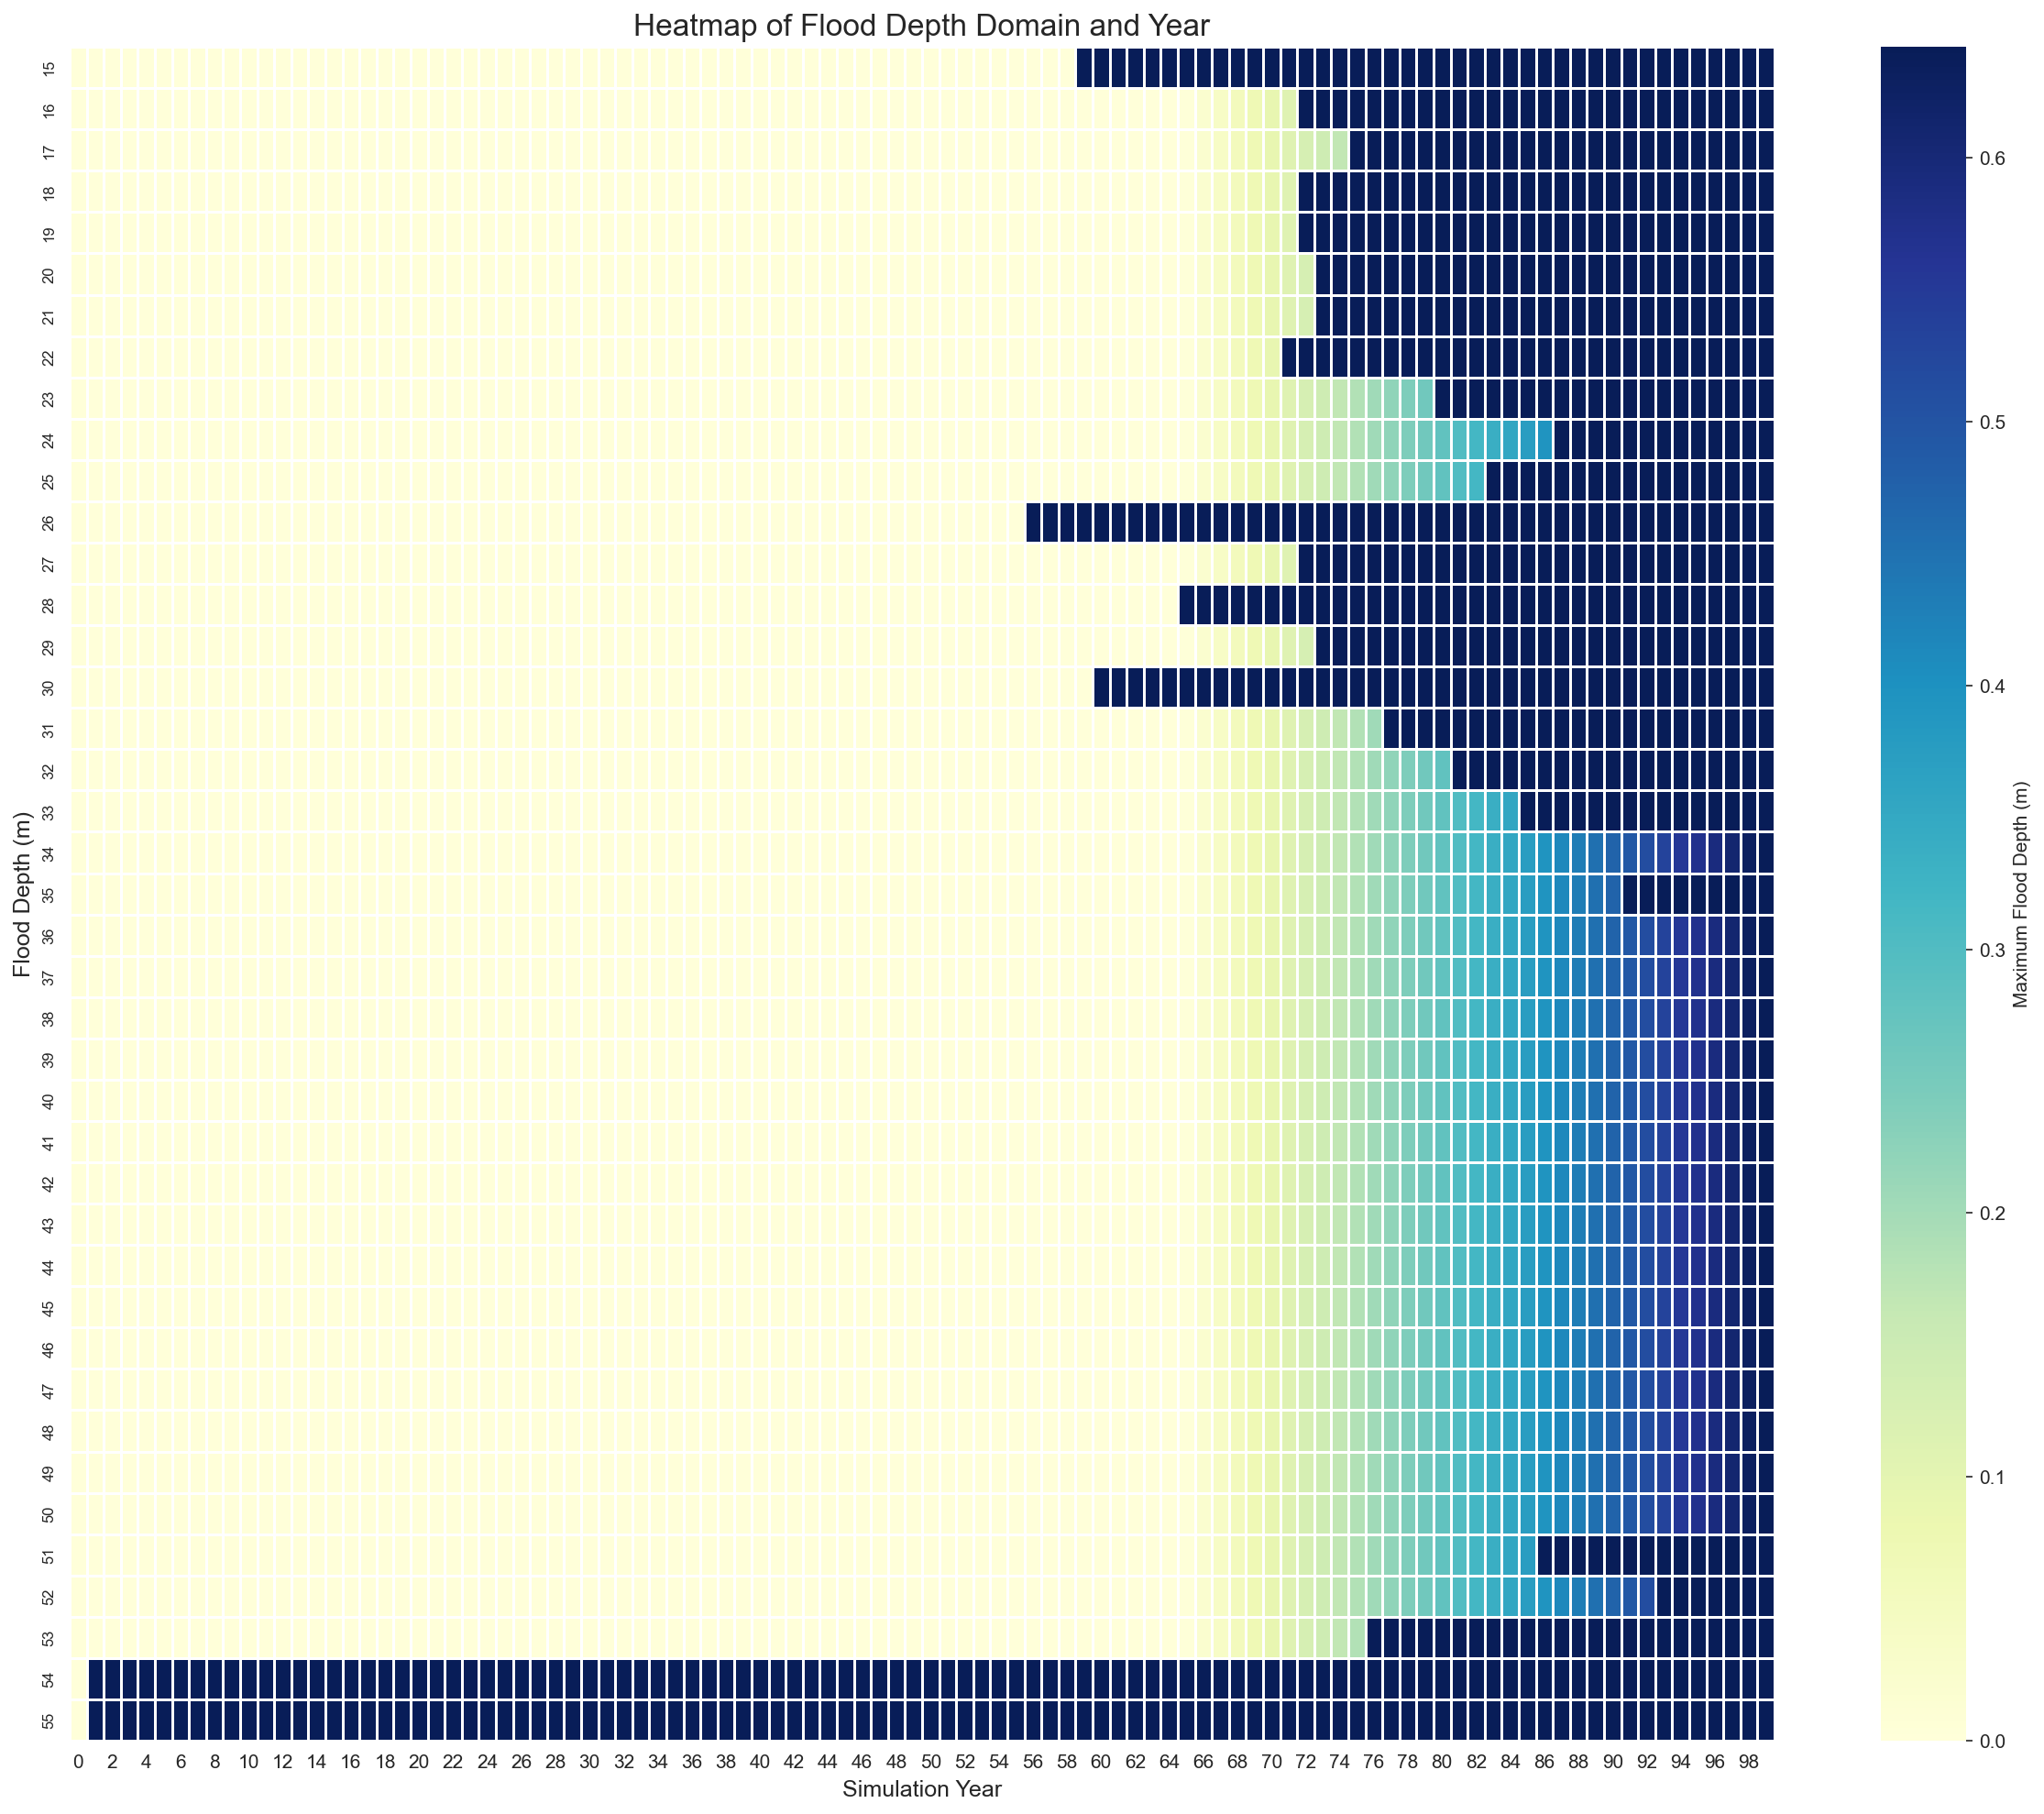

In [127]:
#plotting flood depth
df_flood_depth = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df_flood_depth.pivot_table(index='Domain', columns='Year', values='Max_Flood_Depth_m_MHW')

# Create the heatmap plot
plt.figure(figsize=(20, 16), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot=False, fmt=".2f", cmap='YlGnBu', 
            linewidths=.5, cbar_kws={'label': 'Maximum Flood Depth (m)'})


ax.tick_params(axis='y', labelsize=8)

plt.title('Heatmap of Flood Depth Domain and Year', fontsize=16)
plt.ylabel('Flood Depth (m)', fontsize=12)
plt.xlabel('Simulation Year', fontsize=12)

# Show the plot
plt.show()